# Lecture 11: More Data Processing, Markdown

## Joining Data
Suppose we want to investigate the effect on climate (eg. temperatures, rainfall) on daily cyclist and pedestrian counts. We could import daily weather data 'BrisbaneDailyWeather.csv' which is gathered from the Bureau of Meteorology. We could then join the datasets together. We need to have an index or column (or set of columns) in common between the datasets in order to join them.

Different types of joins / merge
* inner (default)
* left (use keys from left frame)
* right (use keys from right frame)
* outer (use keys from both frames)

Join is used to join by index, whereas merge is used to join by columns.

Can use left_on and right_on arguments if the joining columns have different names.

**Exercise:**
1. Import the 'bike-ped-auto-counts-2021.csv' dataset. Ensure the Date column is imported in datetime format and is set as the index of the dataframe.
2. Import the 'BrisbaneDailyWeather.csv' file, converting the Data column to datetime format and setting it as the index.
3. Join the datasets together, and then determine how climate effects the counts

In [5]:
# insert code here
import pandas as pd
counts = pd.read_csv('Data/bike-ped-auto-counts-2021.csv', index_col='Date', parse_dates=True)
counts

,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian","A023, Botanic Gardens, City _Cyclist","A003, Ekibin Park, Greenslopes _Pedestrian","A003, Ekibin Park, Greenslopes _Cyclist",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,1375.0,1718.0,1180.0,1780.0,1030,96,2955.0,1518.0,732,186.0,...,NaN,NaN,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,1668.0,2649.0,1445.0,2865.0,795,98,3267.0,2136.0,672,243.0,...,NaN,NaN,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,1939.0,3062.0,1251.0,3217.0,518,163,3172.0,2448.0,762,251.0,...,NaN,NaN,329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,2007.0,2587.0,1218.0,2780.0,469,147,2583.0,1792.0,843,215.0,...,NaN,NaN,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,1570.0,3474.0,1080.0,3648.0,389,134,1959.0,2163.0,636,179.0,...,NaN,NaN,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,NaN,NaN,1304.0,2211.0,421,103,2798.0,1457.0,389,215.0,...,851.0,752.0,202,NaN,NaN,158.0,201.0,292.0,215.0,749.0
2021-12-28,NaN,NaN,1478.0,1273.0,414,89,3390.0,1210.0,348,205.0,...,796.0,503.0,147,NaN,NaN,214.0,308.0,481.0,265.0,975.0
2021-12-29,NaN,NaN,1530.0,2596.0,499,118,3519.0,1945.0,407,310.0,...,771.0,971.0,328,NaN,NaN,226.0,347.0,464.0,269.0,1032.0


In [6]:
weather = pd.read_csv('Data/BrisbaneDailyWeather.csv', index_col='Date', parse_dates=True)
weather

,MinTemp,MaxTemp,Rainfall
Date,,,
2022-02-13,18.6,29.3,7.2
2022-02-12,20.4,28.9,0.0
2022-02-11,19.1,31.3,0.0
2022-02-10,19.4,31.2,0.0
2022-02-09,18.6,30.0,0.0
...,...,...,...
1999-12-15,17.0,27.0,0.0
1999-12-14,17.0,26.0,0.2
1999-12-13,19.0,24.0,0.8


In [7]:
# joining left_df.join(right_df)
weather.join(counts)

,MinTemp,MaxTemp,Rainfall,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
2022-02-13,18.6,29.3,7.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-12,20.4,28.9,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-11,19.1,31.3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-10,19.4,31.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-09,18.6,30.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999-12-15,17.0,27.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-12-14,17.0,26.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-12-13,19.0,24.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
counts.join(weather)

,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian","A023, Botanic Gardens, City _Cyclist","A003, Ekibin Park, Greenslopes _Pedestrian","A003, Ekibin Park, Greenslopes _Cyclist",...,"A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City",MinTemp,MaxTemp,Rainfall
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,1375.0,1718.0,1180.0,1780.0,1030,96,2955.0,1518.0,732,186.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.7,29.4,2.4
2021-01-02,1668.0,2649.0,1445.0,2865.0,795,98,3267.0,2136.0,672,243.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.5,29.9,1.8
2021-01-03,1939.0,3062.0,1251.0,3217.0,518,163,3172.0,2448.0,762,251.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.2,30.1,0.0
2021-01-04,2007.0,2587.0,1218.0,2780.0,469,147,2583.0,1792.0,843,215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.2,30.2,0.0
2021-01-05,1570.0,3474.0,1080.0,3648.0,389,134,1959.0,2163.0,636,179.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.4,32.8,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,NaN,NaN,1304.0,2211.0,421,103,2798.0,1457.0,389,215.0,...,NaN,NaN,158.0,201.0,292.0,215.0,749.0,21.3,28.9,0.0
2021-12-28,NaN,NaN,1478.0,1273.0,414,89,3390.0,1210.0,348,205.0,...,NaN,NaN,214.0,308.0,481.0,265.0,975.0,19.6,25.7,14.6
2021-12-29,NaN,NaN,1530.0,2596.0,499,118,3519.0,1945.0,407,310.0,...,NaN,NaN,226.0,347.0,464.0,269.0,1032.0,19.1,26.9,0.0


In [9]:
# use index of the right dataframe
weather.join(counts, how='right')

,MinTemp,MaxTemp,Rainfall,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,21.7,29.4,2.4,1375.0,1718.0,1180.0,1780.0,1030,96,2955.0,...,NaN,NaN,160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,21.5,29.9,1.8,1668.0,2649.0,1445.0,2865.0,795,98,3267.0,...,NaN,NaN,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,22.2,30.1,0.0,1939.0,3062.0,1251.0,3217.0,518,163,3172.0,...,NaN,NaN,329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,23.2,30.2,0.0,2007.0,2587.0,1218.0,2780.0,469,147,2583.0,...,NaN,NaN,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,23.4,32.8,1.0,1570.0,3474.0,1080.0,3648.0,389,134,1959.0,...,NaN,NaN,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,21.3,28.9,0.0,NaN,NaN,1304.0,2211.0,421,103,2798.0,...,851.0,752.0,202,NaN,NaN,158.0,201.0,292.0,215.0,749.0
2021-12-28,19.6,25.7,14.6,NaN,NaN,1478.0,1273.0,414,89,3390.0,...,796.0,503.0,147,NaN,NaN,214.0,308.0,481.0,265.0,975.0
2021-12-29,19.1,26.9,0.0,NaN,NaN,1530.0,2596.0,499,118,3519.0,...,771.0,971.0,328,NaN,NaN,226.0,347.0,464.0,269.0,1032.0


In [10]:
# inner join keeps index values that are in both dataframes
weather.join(counts, how='inner')

,MinTemp,MaxTemp,Rainfall,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
2021-12-31,18.9,25.6,0.0,NaN,NaN,NaN,NaN,370,109,3275.0,...,563.0,790.0,269,NaN,NaN,187.0,292.0,392.0,301.0,705.0
2021-12-30,17.8,27.7,0.0,NaN,NaN,NaN,NaN,534,148,3651.0,...,852.0,741.0,311,NaN,NaN,256.0,331.0,396.0,311.0,1106.0
2021-12-29,19.1,26.9,0.0,NaN,NaN,1530.0,2596.0,499,118,3519.0,...,771.0,971.0,328,NaN,NaN,226.0,347.0,464.0,269.0,1032.0
2021-12-28,19.6,25.7,14.6,NaN,NaN,1478.0,1273.0,414,89,3390.0,...,796.0,503.0,147,NaN,NaN,214.0,308.0,481.0,265.0,975.0
2021-12-27,21.3,28.9,0.0,NaN,NaN,1304.0,2211.0,421,103,2798.0,...,851.0,752.0,202,NaN,NaN,158.0,201.0,292.0,215.0,749.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-05,23.4,32.8,1.0,1570.0,3474.0,1080.0,3648.0,389,134,1959.0,...,NaN,NaN,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,23.2,30.2,0.0,2007.0,2587.0,1218.0,2780.0,469,147,2583.0,...,NaN,NaN,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,22.2,30.1,0.0,1939.0,3062.0,1251.0,3217.0,518,163,3172.0,...,NaN,NaN,329,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# return index values from both dataframes
weather.join(counts, how='outer')

,MinTemp,MaxTemp,Rainfall,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
1999-12-11,22.0,26.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-12-12,18.0,29.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-12-13,19.0,24.0,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-12-14,17.0,26.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999-12-15,17.0,27.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-02-09,18.6,30.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-10,19.4,31.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-11,19.1,31.3,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
joined_df = weather.join(counts, how='inner')
joined_df

,MinTemp,MaxTemp,Rainfall,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
Date,,,,,,,,,,,,,,,,,,,,,
2021-12-31,18.9,25.6,0.0,NaN,NaN,NaN,NaN,370,109,3275.0,...,563.0,790.0,269,NaN,NaN,187.0,292.0,392.0,301.0,705.0
2021-12-30,17.8,27.7,0.0,NaN,NaN,NaN,NaN,534,148,3651.0,...,852.0,741.0,311,NaN,NaN,256.0,331.0,396.0,311.0,1106.0
2021-12-29,19.1,26.9,0.0,NaN,NaN,1530.0,2596.0,499,118,3519.0,...,771.0,971.0,328,NaN,NaN,226.0,347.0,464.0,269.0,1032.0
2021-12-28,19.6,25.7,14.6,NaN,NaN,1478.0,1273.0,414,89,3390.0,...,796.0,503.0,147,NaN,NaN,214.0,308.0,481.0,265.0,975.0
2021-12-27,21.3,28.9,0.0,NaN,NaN,1304.0,2211.0,421,103,2798.0,...,851.0,752.0,202,NaN,NaN,158.0,201.0,292.0,215.0,749.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-01-05,23.4,32.8,1.0,1570.0,3474.0,1080.0,3648.0,389,134,1959.0,...,NaN,NaN,505,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,23.2,30.2,0.0,2007.0,2587.0,1218.0,2780.0,469,147,2583.0,...,NaN,NaN,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,22.2,30.1,0.0,1939.0,3062.0,1251.0,3217.0,518,163,3172.0,...,NaN,NaN,329,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
joined_df.corr()

,MinTemp,MaxTemp,Rainfall,"A001, Bicentennial Bikeway, Auchenflower _Pedestrian","A001, Bicentennial Bikeway, Auchenflower _Cyclist","A019, Bicentennial Bikeway, Milton _Pedestrian","A019, Bicentennial Bikeway, Milton _Cyclist","A002, Bishop Street, Kelvin Grove _Pedestrian","A002, Bishop Street, Kelvin Grove _Cyclist","A023, Botanic Gardens, City _Pedestrian",...,"A028, Indooroopilly Riverwalk, Indooroopilly _Pedestrian","A028, Indooroopilly Riverwalk, Indooroopilly _Cyclist","A029, Lytton Road, East Brisbane _Cyclist","A200,_Cyclist City Link Cycleway (Edward St - Charlotte to Mary), City","A200,_Scooter City Link Cycleway (Edward St - Charlotte to Mary), City","A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City","A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City","A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City","A203,_Cyclist City Link Cycleway (Victoria Bridge), City","A203,_Scooter City Link Cycleway (Victoria Bridge), City"
MinTemp,1.000000,0.722488,0.203810,-0.377349,-0.016720,-0.740461,-0.115567,-0.187981,-0.126055,-0.362022,...,-0.400537,-0.373571,-0.114578,NaN,NaN,-0.304823,-0.055611,-0.123100,0.067810,0.344637
MaxTemp,0.722488,1.000000,0.003473,-0.105804,0.325643,-0.492154,0.214303,-0.054820,0.177097,-0.194076,...,-0.251802,-0.123153,0.079526,NaN,NaN,-0.102961,-0.068041,0.025779,0.202158,0.475515
Rainfall,0.203810,0.003473,1.000000,-0.283521,-0.332651,-0.240287,-0.350002,-0.274812,-0.385750,-0.193944,...,-0.211749,-0.307676,-0.222898,NaN,NaN,-0.146598,-0.162662,-0.183551,-0.093156,-0.082545
"A001, Bicentennial Bikeway, Auchenflower _Pedestrian",-0.377349,-0.105804,-0.283521,1.000000,0.439574,0.703624,0.358207,0.482298,0.685509,0.470047,...,0.457520,0.514396,0.251874,NaN,NaN,0.270347,0.317419,0.061334,-0.054049,-0.423279
"A001, Bicentennial Bikeway, Auchenflower _Cyclist",-0.016720,0.325643,-0.332651,0.439574,1.000000,0.211543,0.981238,0.059405,0.611890,0.230955,...,0.027110,0.306449,0.789376,NaN,NaN,0.539681,0.439711,0.167786,0.396687,0.320388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"A201,_Cyclist City Link Cycleway (Elizabeth St - Creek to Edward), City",-0.304823,-0.102961,-0.146598,0.270347,0.539681,0.274060,0.477135,-0.096452,0.161342,-0.037689,...,-0.124350,-0.114353,0.453402,NaN,NaN,1.000000,0.159628,0.279617,0.257158,0.221296
"A202,_Cyclist City Link Cycleway (Elizabeth St - Edward to Albert), City",-0.055611,-0.068041,-0.162662,0.317419,0.439711,0.416681,0.567478,0.043148,0.417385,-0.128155,...,0.101271,0.055194,0.443708,NaN,NaN,0.159628,1.000000,0.016557,0.653645,0.229309
"A202,_Scooter City Link Cycleway (Elizabeth St - Edward to Albert), City",-0.123100,0.025779,-0.183551,0.061334,0.167786,0.269955,0.403541,0.144158,0.274343,0.109925,...,0.206172,0.062505,0.490070,NaN,NaN,0.279617,0.016557,1.000000,0.495362,0.486548
"A203,_Cyclist City Link Cycleway (Victoria Bridge), City",0.067810,0.202158,-0.093156,-0.054049,0.396687,0.171136,0.481766,-0.076140,0.170006,-0.138684,...,-0.214019,-0.136659,0.458260,NaN,NaN,0.257158,0.653645,0.495362,1.000000,0.504638


In [14]:
# correlation between auchenflower and milton ccyclists very high
joined_df.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall',
       'A001, Bicentennial Bikeway, Auchenflower  _Pedestrian',
       'A001, Bicentennial Bikeway, Auchenflower  _Cyclist',
       'A019, Bicentennial Bikeway, Milton  _Pedestrian',
       'A019, Bicentennial Bikeway, Milton  _Cyclist',
       'A002, Bishop Street, Kelvin Grove  _Pedestrian',
       'A002, Bishop Street, Kelvin Grove  _Cyclist',
       'A023, Botanic Gardens, City  _Pedestrian',
       'A023, Botanic Gardens, City  _Cyclist',
       'A003, Ekibin Park, Greenslopes  _Pedestrian',
       'A003, Ekibin Park, Greenslopes  _Cyclist',
       'A004, Eleanor Schonell Br Cyclists, St Lucia  _Cyclist',
       'A004, Eleanor Schonell Br Pedestrians, St Lucia  _Pedestrian',
       'A005, Go Between Br Cyclists, South Brisbane   _Cyclist',
       'A005, Go Between Br Pedestrians, South Brisbane  _Pedestrian',
       'A006, Granville St Bridge, Herston  _Pedestrian',
       'A006, Granville St Bridge, Herston  _Cyclist',
       'A020, Gympie

<Axes: xlabel='A019, Bicentennial Bikeway, Milton  _Cyclist', ylabel='A001, Bicentennial Bikeway, Auchenflower  _Cyclist'>

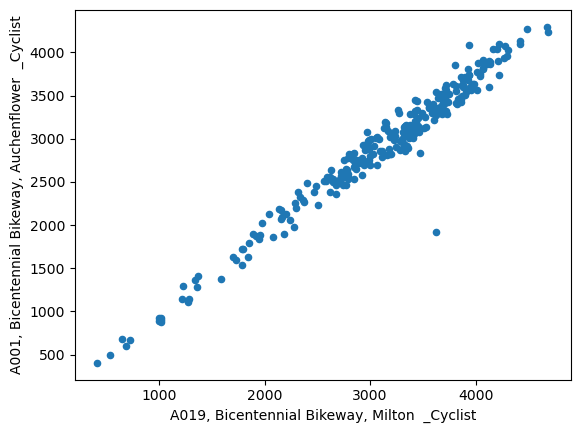

In [15]:
joined_df.plot(x='A019, Bicentennial Bikeway, Milton  _Cyclist', y='A001, Bicentennial Bikeway, Auchenflower  _Cyclist', kind='scatter')

## Seaborn and mode advanced visuals
Seaborn is a high-level data visualisation library. Like the pandas plot method, many features of graphs will be automated such as labels. 

Since Seaborn is dedicated to visualisation, you can create much more advanced visuals than is possible with pandas. You can easily create plots relating 3, 4 or 5 variables by utilising hue, row and col arguments in addition to x and y.

Seaborn is designed to work with long format data (all categories of a variable in one column), while pandas is designed for wide format data (each category gets a separate column). Can convert between the two with <code>melt</code> and <code>pivot</code> functions in pandas.

Some useful resources from the official website include:
* Introduction to seaborn: https://seaborn.pydata.org/tutorial/introduction.html
* Examples: https://seaborn.pydata.org/examples/index.html


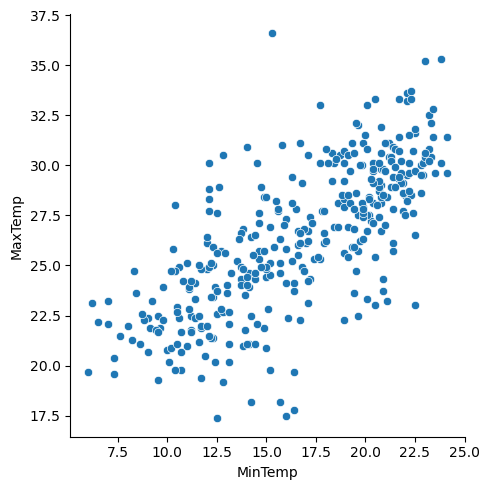

In [16]:
# examples here
# matplotlib and seaborn are dedicated visualiation libaries - can use for advanced visual
import seaborn as sns
sns.relplot(joined_df, x='MinTemp', y='MaxTemp')

<Axes: xlabel='MinTemp', ylabel='MaxTemp'>

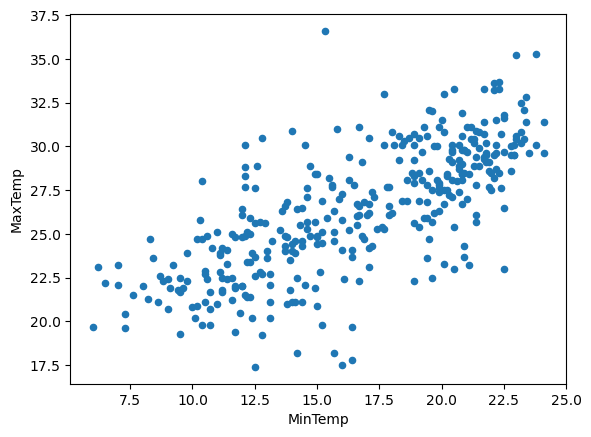

In [18]:
joined_df.plot(x='MinTemp', y='MaxTemp', kind='scatter')

In [20]:
# seaborn better at handling multivariate data (three or more variables)
weather['Year'] = weather.index.year
weather['Month'] = weather.index.month
# filter for 2020 onwards
weather = weather[weather.Year >= 2020]
weather

,MinTemp,MaxTemp,Rainfall,Year,Month
Date,,,,,
2022-02-13,18.6,29.3,7.2,2022,2
2022-02-12,20.4,28.9,0.0,2022,2
2022-02-11,19.1,31.3,0.0,2022,2
2022-02-10,19.4,31.2,0.0,2022,2
2022-02-09,18.6,30.0,0.0,2022,2
...,...,...,...,...,...
2020-01-05,21.9,31.5,0.0,2020,1
2020-01-04,21.4,31.4,0.0,2020,1
2020-01-03,20.9,30.7,0.0,2020,1


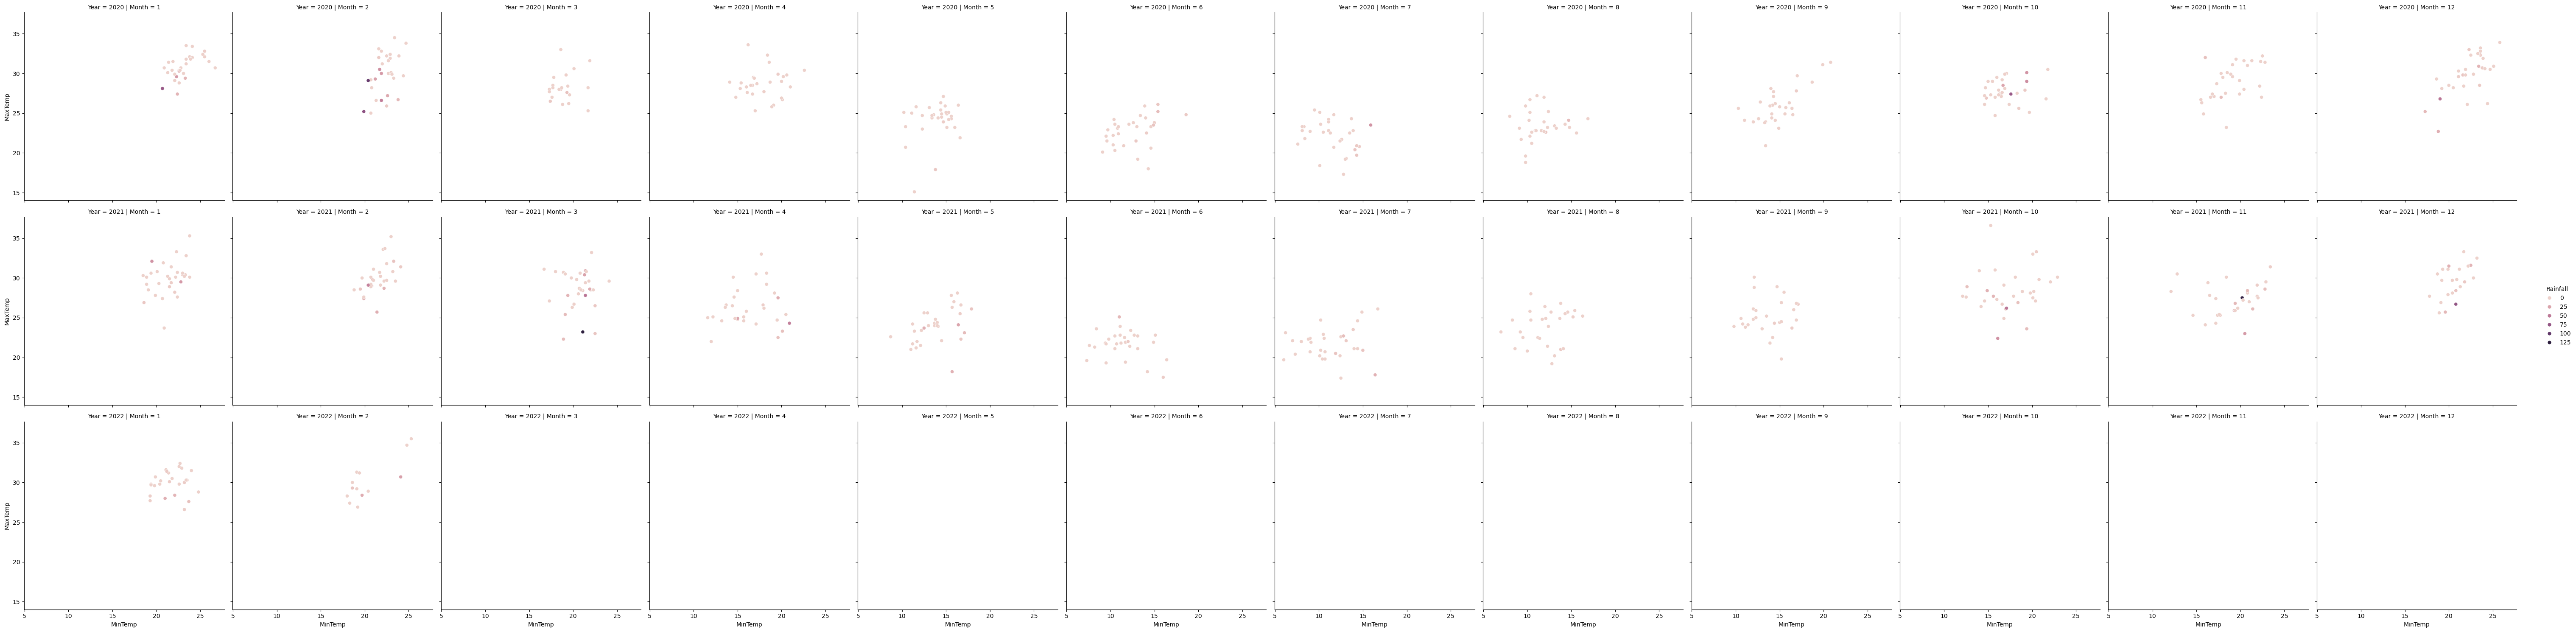

In [24]:
sns.relplot(weather, x='MinTemp', y='MaxTemp', hue='Rainfall', col='Month', row='Year')

## Markdown
Markdown is a programming language used to create formatted text. JupyterLab notebooks allow you to write Markdown code by adding a Markdown cell.

The official website contains some useful learning resources:
* Basic syntax: https://www.markdownguide.org/basic-syntax/
* Cheat sheet: https://www.markdownguide.org/cheat-sheet/

You can also learn by example by clicking on any Markdown cells in notebooks provided to you over the course of the semester.

Written content should go in a Markdown cell.

Some basic formatting features:

# A heading

## A subbheadding

### A subsubheading

A bullet point list:
* item1
* item2
* item3

A numbered list:
1. item1
2. item2
3. item3

**some bold text**

Can do heaps of fancier things too - images, tables coloring. Not needed for assignment but can explore if interested.

In [25]:
Written content should not go in a code cell!

SyntaxError: invalid syntax (767936236.py, line 1)

In [26]:
# Comments are okay to clarify what the code does. They should not be used to answer the question.